# WARS1: exercise response, circulating forms, and disease hypotheses

**Conclusion:** WARS1 is a plausible candidate exercise-responsive signaling protein, with one significant acute plasma response and later muscle RNA responses. Its molecular form and tissue of release are unresolved. It also has disease-relevant biology involving innate immunity, vascular function, and insulin signaling. These mechanisms must be kept separate: higher plasma WARS1 does not automatically mean improved or impaired insulin sensitivity.

This follow-up uses available **human MoTrPAC acute-exercise c2.0 summaries**, original assay-wide BH values independently verified from raw p-values, and published genetic association tables. It adds no participant-level data and performs no new GWAS, Mendelian randomization, or colocalization. WARS1 was selected in the preceding screen; this is deeper analysis of the same cohort, not independent replication.

Start with the observed time courses below, then the molecular-form and disease-evidence sections. The companion [findings report](results/wars1/FINDINGS.md) gives a shorter explanation and proposed experiments. Analysis date: 26 September 2026.

## Identity, assay, and comparison

WARS1 encodes the **cytoplasmic tryptophanyl-tRNA synthetase**, which normally attaches tryptophan to tRNA for protein synthesis. Aliases include **WARS, WRS, IFI53, and TrpRS**. It is distinct from mitochondrial **WARS2**. The source mapping identifies plasma Olink **OID21084**, UniProt **P23381**, and RNA feature **ENSG00000140105.18**. [UniProt](https://www.uniprot.org/uniprotkb/P23381/entry).

The Olink measurement is a relative protein-assay signal, not a direct measurement of catalytic activity or absolute concentration. The public assay page does not establish which full-length, spliced, or cleaved forms are recognized in these samples. Gene-level RNA and bulk protein results also do not resolve these forms. [Olink assay](https://olink.com/assay/explore/neurology/tryptophan-trna-ligase-cytoplasmic).

For the primary resistance comparison, the null is

\[
H_0:(RE_t-RE_{baseline})-(CON_t-CON_{baseline})=0.
\]

Positive effects indicate greater change than in resting controls. We retain the source `logFC` scale without converting it to a percentage or combining effect sizes across assays. Pointwise 95% confidence intervals are not multiplicity-adjusted. The cohort has 175 people overall; usable participant counts vary across assays and timepoints.

In [1]:
from pathlib import Path
import sys, json, subprocess, shutil, importlib.util
sys.dont_write_bytecode=True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
ROOT=Path.cwd()
if not (ROOT/'motrpac-exploration').exists(): ROOT=ROOT/'bic'
assert (ROOT/'motrpac-exploration').exists()
OUT=ROOT/'results/wars1'
spec=importlib.util.spec_from_file_location('wars_analysis', ROOT/'analysis/analyze_wars1.py')
analysis=importlib.util.module_from_spec(spec);spec.loader.exec_module(analysis)
print('Verified source inputs:',len(analysis.verify_inputs(ROOT)))
rscript=shutil.which('Rscript');assert rscript
run=subprocess.run([rscript,str(ROOT/'analysis/extract_wars1.R'),str(ROOT/'motrpac-exploration'),str(OUT)],
                   check=True,capture_output=True,text=True)
print(run.stdout)
res=analysis.build(ROOT)
data, primary, plasma = res['data'],res['primary'],res['plasma']
pd.set_option('display.max_rows',60);pd.set_option('display.max_colwidth',90)
print(json.dumps(res['counts'],indent=2))
display(pd.read_csv(OUT/'wars1_assay_coverage.csv'))

Verified source inputs: 13


BLOOD_PROT_OL_DA : 33 WARS1 source contrasts
BLOOD_TRNSCRPT_DA : 33 WARS1 source contrasts
MUSCLE_TRNSCRPT_DA : 21 WARS1 source contrasts
ADIPOSE_TRNSCRPT_DA : 21 WARS1 source contrasts
MUSCLE_PROT_PR_DA : 21 WARS1 source contrasts
ADIPOSE_PROT_PR_DA : 9 WARS1 source contrasts
MUSCLE_PROT_PH_DA : 42 WARS1 source contrasts
ADIPOSE_PROT_PH_DA : no analyzed WARS1 features
Saved separate exploratory metabolite context, retaining original source q values.



{
  "source_WARS1_contrasts": 180,
  "primary_WARS1_contrasts": 52,
  "primary_BH_hits": 3,
  "BH_families_verified": 159,
  "background_feature_tests_verified": 2068077,
  "maximum_BH_difference": 4.88498130835069e-15,
  "prior_screen_rows_reproduced": 58
}


,source_object,tissue,assay,source_features,mapped_features,analyzed_WARS1_features,source_WARS1_rows
0,BLOOD_PROT_OL_DA,blood,prot-ol,1417,1,1,33
1,BLOOD_TRNSCRPT_DA,blood,transcript-rna-seq,20526,1,1,33
2,MUSCLE_TRNSCRPT_DA,muscle,transcript-rna-seq,16509,1,1,21
3,ADIPOSE_TRNSCRPT_DA,adipose,transcript-rna-seq,20090,1,1,21
4,MUSCLE_PROT_PR_DA,muscle,prot-pr,6211,1,1,21
5,ADIPOSE_PROT_PR_DA,adipose,prot-pr,7056,1,1,9
6,MUSCLE_PROT_PH_DA,muscle,prot-ph,18164,4,2,42
7,ADIPOSE_PROT_PH_DA,adipose,prot-ph,8713,4,0,0


## All exercise effects, with baseline differences excluded

The extractor checks complete assay families before selecting WARS1. Its audit spans **159 families and 2,068,077 feature–contrast tests**, including baseline and within-arm contrasts; maximum source-BH discrepancy is below 5 × 10⁻¹⁵. The 58 WARS1 rows shared with the prior screen match.

**Filter by `contrast_type`, not just the category label.** Source baseline comparisons also use `EE-CON` and `RE-CON`. An adipose protein baseline difference passes BH but is not an exercise response. It stays in a separate export.

Among **52 primary exercise-versus-control WARS1 estimates**, three pass source BH < 0.05: plasma RE at 10 minutes and muscle RNA at 3.5 hours after each exercise mode. Muscle total protein, blood RNA, adipose RNA/protein, and the two measured muscle phosphosites have no primary BH hits. Nonsignificance is not evidence that secretion is absent.

In [2]:
assert primary.contrast_type.eq('exercise_with_controls').all()
assert not primary.Timepoint.eq('pre_exercise').any()
columns=['tissue','assay','feature_id','contrast_category','sample_time','logFC',
         'CI.L_calculated','CI.R_calculated','p_value','adj_p_value']
display(primary[primary.source_significant][columns])
display(primary.groupby(['tissue','assay']).agg(
    available_estimates=('feature_id','size'),BH_hits=('source_significant','sum')).reset_index())
display(plasma[['contrast_category','sample_time','logFC','CI.L_calculated','CI.R_calculated',
                'p_value','adj_p_value','pooled_primary_plasma_bh']])

,tissue,assay,feature_id,contrast_category,sample_time,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value
6,blood,prot-ol,OID21084,RE-CON,Post 10 min,0.566828,0.241716,0.891941,7.337049e-04,0.031163
67,muscle,transcript-rna-seq,ENSG00000140105.18,EE-CON,Post 3.5 h,0.374024,0.245246,0.502802,3.038485e-08,0.000001
70,muscle,transcript-rna-seq,ENSG00000140105.18,RE-CON,Post 3.5 h,0.329233,0.205899,0.452567,3.147579e-07,0.000004


,tissue,assay,available_estimates,BH_hits
0,adipose,prot-pr,2,0
1,adipose,transcript-rna-seq,6,0
2,blood,prot-ol,10,1
3,blood,transcript-rna-seq,10,0
4,muscle,prot-ph,12,0
5,muscle,prot-pr,6,0
6,muscle,transcript-rna-seq,6,2


,contrast_category,sample_time,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value,pooled_primary_plasma_bh
0,EE-CON,During 20 min,0.247576,-0.094020,0.589172,0.154284,0.482228,0.587670
1,EE-CON,During 40 min,0.387097,0.037626,0.736567,0.030154,0.135725,0.306291
2,EE-CON,Post 10 min,0.243202,-0.098394,0.584798,0.161648,0.719087,0.594641
3,EE-CON,Post 30 min,0.023104,-0.325105,0.371314,0.895909,0.971494,0.968421
4,EE-CON,Post 3.5 h,-0.026744,-0.469769,0.416282,0.905264,0.974001,0.971359
5,EE-CON,Post 24 h,0.003760,-0.413048,0.420569,0.985809,0.998993,0.994724
6,RE-CON,Post 10 min,0.566828,0.241716,0.891941,0.000734,0.031163,0.040771
7,RE-CON,Post 30 min,0.226767,-0.093433,0.546966,0.163855,0.491914,0.597461
8,RE-CON,Post 3.5 h,0.005549,-0.393950,0.405048,0.978153,0.995658,0.992749
9,RE-CON,Post 24 h,0.099980,-0.309956,0.509916,0.630760,0.788383,0.873103


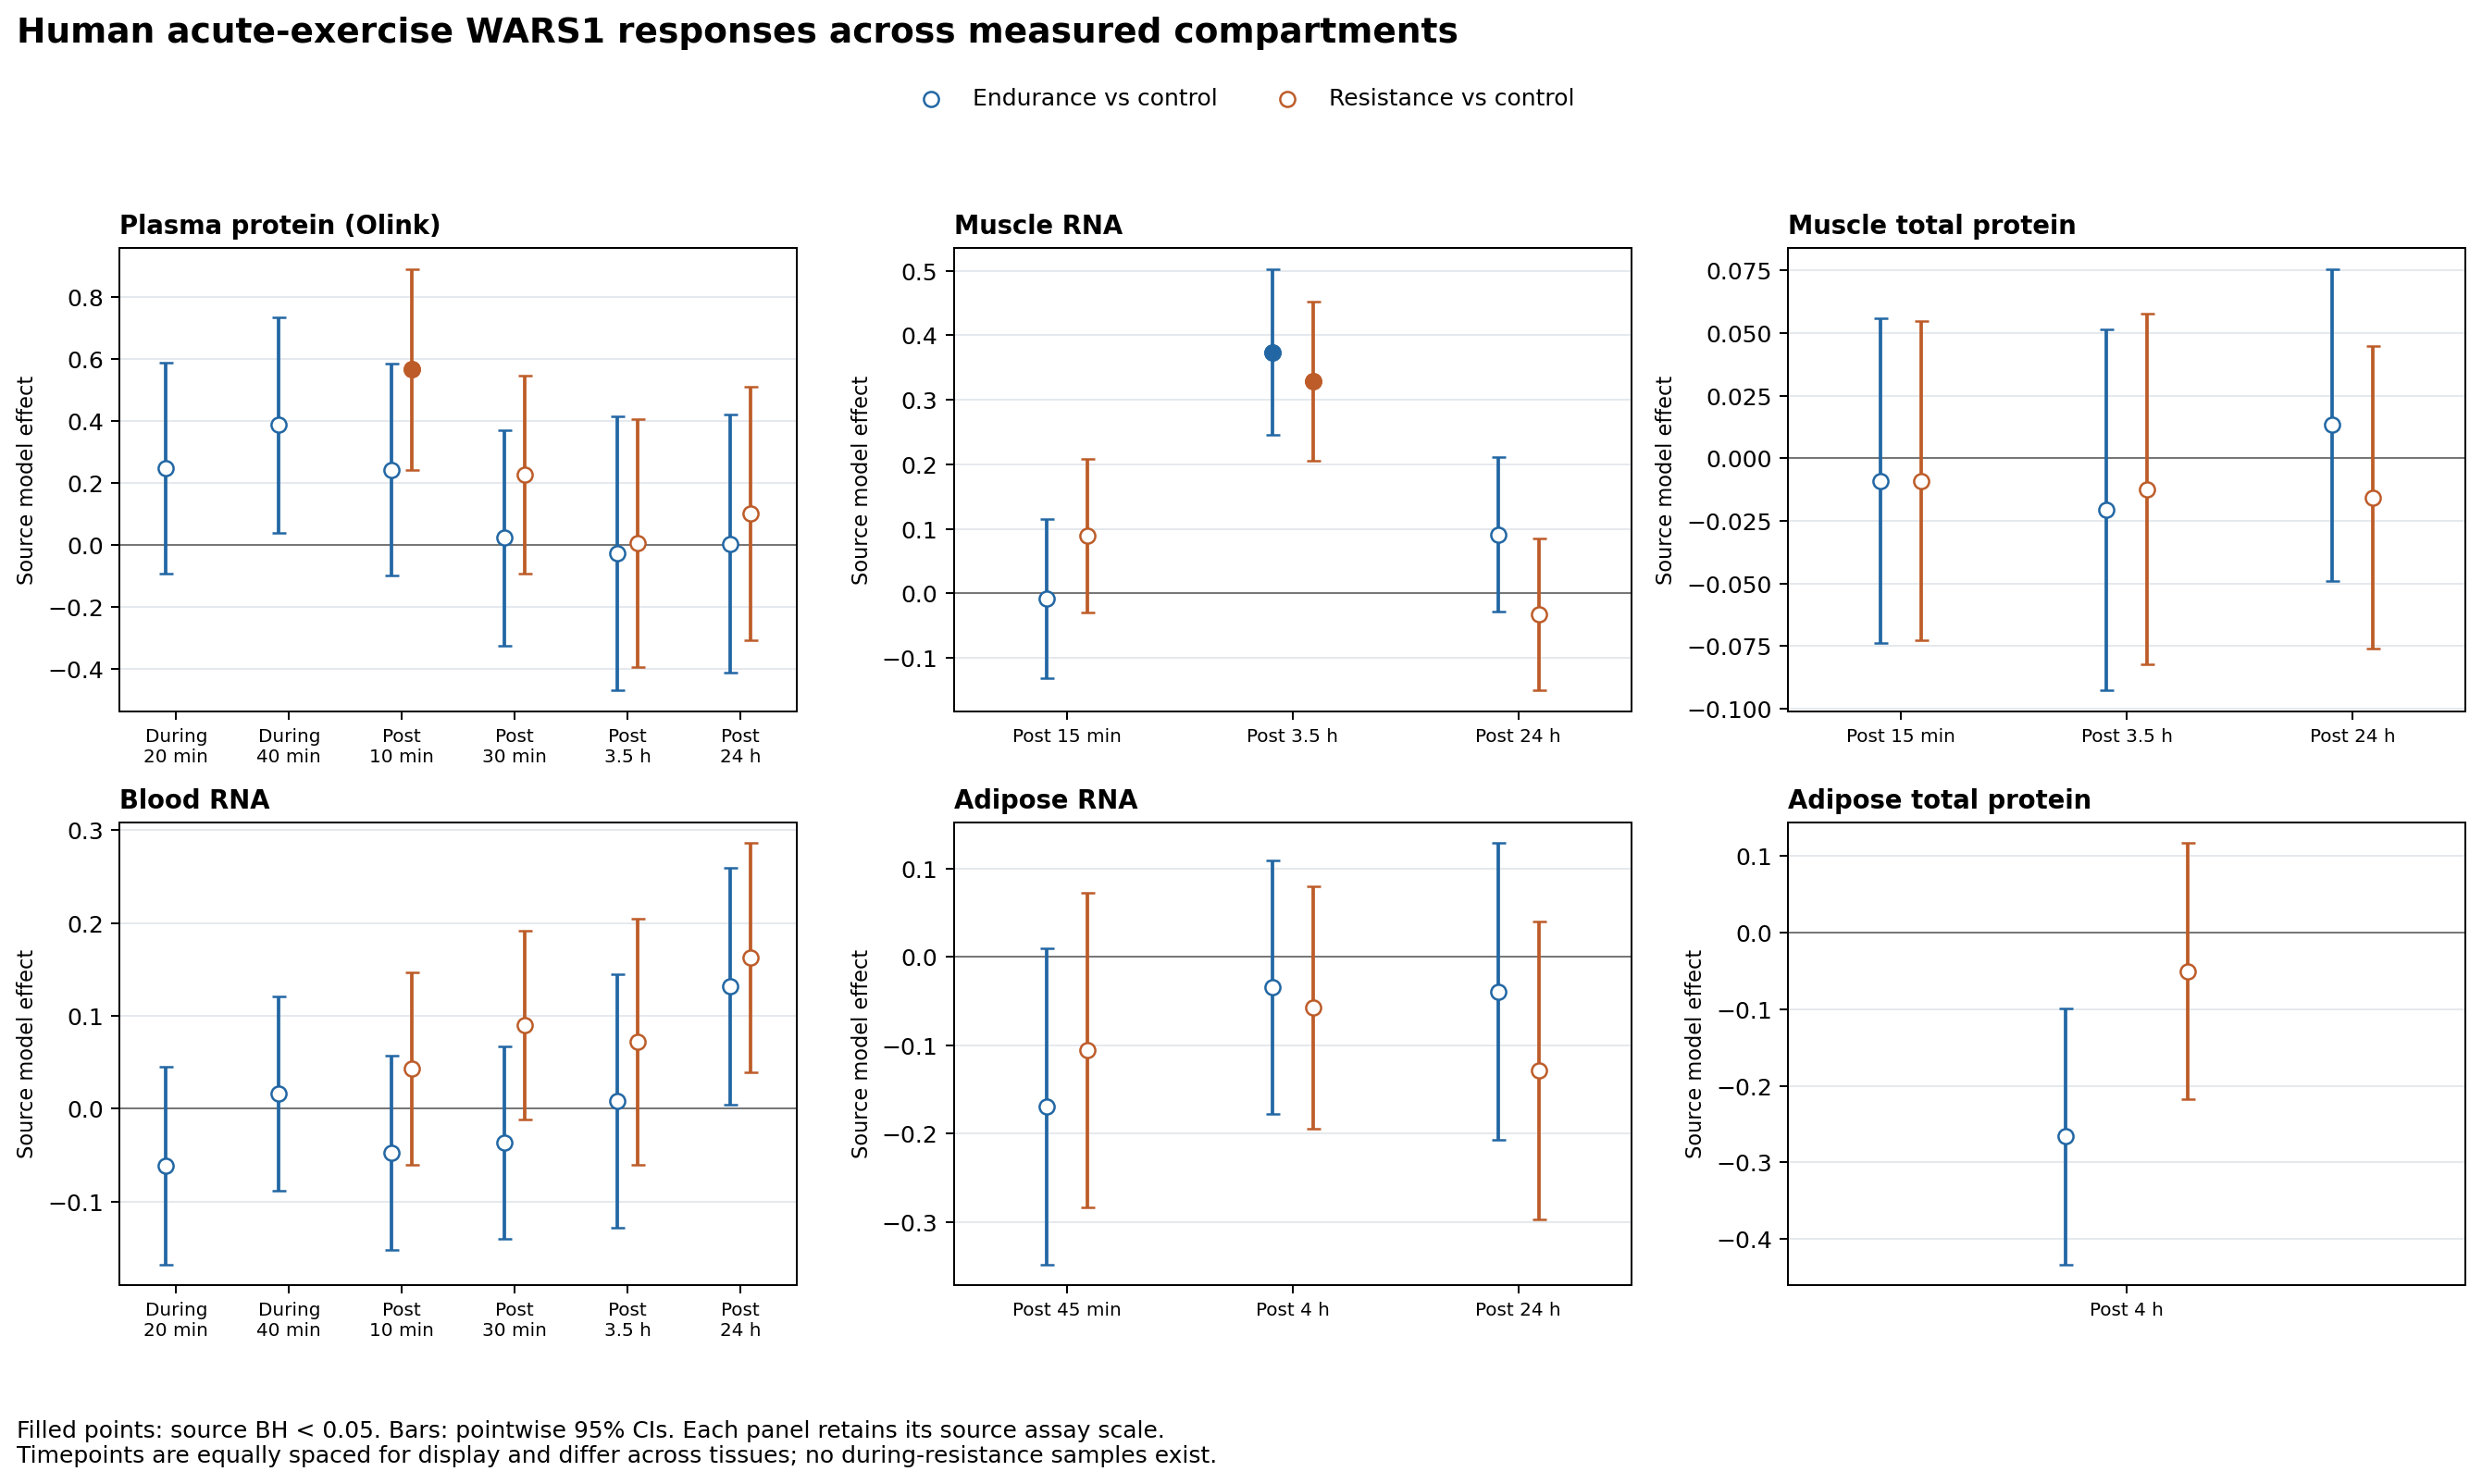

In [3]:
COLORS={'EE-CON':'#2267a4','RE-CON':'#bd5c29'}
TIMES=['during_20_min','during_40_min','post_10_min','post_15_30_45_min','post_3.5_4_hr','post_24_hr']
def save_figure(fig,name):
    fig.savefig(OUT/f'{name}.png',dpi=180,bbox_inches='tight',facecolor='white')
    fig.savefig(OUT/f'{name}.svg',bbox_inches='tight',facecolor='white')
    display(Image(filename=str(OUT/f'{name}.png')));plt.close(fig)

def panel(ax,frame,order,labels,title):
    ax.axhline(0,color='#777',lw=.8)
    for group,offset,label in [('EE-CON',-.09,'Endurance vs control'),('RE-CON',.09,'Resistance vs control')]:
        q=frame[frame.contrast_category.eq(group)].copy()
        q['x']=q.Timepoint.map({t:i for i,t in enumerate(order)});q=q.sort_values('x')
        if q.empty:continue
        x=q.x.to_numpy()+offset;y=q.logFC.to_numpy()
        err=np.vstack([y-q['CI.L_calculated'].to_numpy(),q['CI.R_calculated'].to_numpy()-y])
        assert np.isfinite(err).all() and (err>=-1e-10).all()
        ax.errorbar(x,y,yerr=np.maximum(err,0),fmt='none',color=COLORS[group],capsize=3)
        ax.scatter(x,y,facecolor='white',edgecolor=COLORS[group],s=42,label=label,zorder=3)
        sig=q.source_significant.to_numpy();ax.scatter(x[sig],y[sig],color=COLORS[group],s=42,zorder=4)
    ax.set_xticks(range(len(order)),labels,fontsize=8)
    ax.set_xlim(-.5,len(order)-.5)
    ax.set_title(title,loc='left',fontweight='bold',fontsize=11)
    ax.set_ylabel('Source model effect',fontsize=9);ax.grid(axis='y',color='#e5e9ed');ax.set_axisbelow(True)

fig,axes=plt.subplots(2,3,figsize=(15,8.6))
specs=[('blood','prot-ol','Plasma protein (Olink)'),('muscle','transcript-rna-seq','Muscle RNA'),
       ('muscle','prot-pr','Muscle total protein'),('blood','transcript-rna-seq','Blood RNA'),
       ('adipose','transcript-rna-seq','Adipose RNA'),('adipose','prot-pr','Adipose total protein')]
for ax,(tissue,assay,title) in zip(axes.flat,specs):
    frame=primary[primary.tissue.eq(tissue)&primary.assay.eq(assay)]
    order=[t for t in TIMES if t in set(frame.Timepoint)]
    mapping=frame.set_index('Timepoint').sample_time.to_dict()
    labels=[mapping[t].replace(' ','\\n',1) if tissue=='blood' else mapping[t] for t in order]
    # Literal line breaks for compact blood sampling labels.
    labels=[s.replace('\\n','\n') for s in labels]
    panel(ax,frame,order,labels,title)
handles,labels=axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,ncol=2,loc='upper center',bbox_to_anchor=(.5,.985),frameon=False)
fig.suptitle('Human acute-exercise WARS1 responses across measured compartments',x=.01,ha='left',fontsize=15,fontweight='bold',y=1.02)
fig.text(.01,.01,'Filled points: source BH < 0.05. Bars: pointwise 95% CIs. Each panel retains its source assay scale.\nTimepoints are equally spaced for display and differ across tissues; no during-resistance samples exist.',fontsize=10)
fig.tight_layout(rect=(0,.08,1,.94));save_figure(fig,'wars1_multitissue_timecourses')

## Is the plasma result an actual within-resistance increase?

Yes, on the source assay scale: at 10 minutes, the RE within-arm change is **+0.371** (source q = **0.00812**). The control within-arm estimate is **−0.196** (q = **0.751**). Their difference is the primary RE-CON estimate **+0.567**, 95% CI **0.242–0.892**, raw p **0.000734**, source q **0.0312**. Thus the effect is not solely a consequence of a falling control estimate. The two within-arm tests and the control-adjusted test have different null hypotheses.

The plasma result also retains q **0.0408** in the previous sensitivity correction across all 14,170 primary plasma feature–comparison tests. That is a different testing family, not a new independent study or a guarantee for the post-selected candidate hypothesis.

Muscle RNA rises at 3.5 hours after **both** modes. The direct plasma EE-RE comparison at 10 minutes has q **0.227**; no direct WARS1 comparison passes source BH < 0.05. Therefore, we cannot call WARS1 resistance-specific. During-RE samples were not collected, and later nonsignificant values do not estimate its biological half-life.

In [4]:
display(res['arms'][['contrast_category','contrast_type','logFC','CI.L_calculated','CI.R_calculated','p_value','adj_p_value']])
display(res['direct'][columns].sort_values(['tissue','assay','feature_id','sample_time']))
assert not res['direct'].source_significant.any()
display(primary[primary.assay.eq('prot-ph')][columns])

,contrast_category,contrast_type,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value
6,RE-CON,exercise_with_controls,0.566828,0.241716,0.891941,0.000734,0.031163
16,RE-RE,exercise_no_controls,0.370578,0.160384,0.580773,0.000642,0.008118
29,CON-CON,control_only,-0.196250,-0.444275,0.051775,0.120111,0.751245


,tissue,assay,feature_id,contrast_category,sample_time,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value
133,adipose,prot-pr,P23381,EE-RE,Post 4 h,-0.214971,-0.373979,-0.055963,0.010302,0.184028
101,adipose,transcript-rna-seq,ENSG00000140105.18,EE-RE,Post 24 h,0.089113,-0.056562,0.234787,0.228970,0.999827
100,adipose,transcript-rna-seq,ENSG00000140105.18,EE-RE,Post 4 h,0.023018,-0.091058,0.137093,0.690924,0.999162
99,adipose,transcript-rna-seq,ENSG00000140105.18,EE-RE,Post 45 min,-0.063877,-0.219684,0.091930,0.419574,0.903138
20,blood,prot-ol,OID21084,EE-RE,Post 10 min,-0.323626,-0.638796,-0.008456,0.044230,0.226947
23,blood,prot-ol,OID21084,EE-RE,Post 24 h,-0.096219,-0.506429,0.313990,0.643894,0.901508
22,blood,prot-ol,OID21084,EE-RE,Post 3.5 h,-0.032293,-0.459549,0.394964,0.881551,0.988378
21,blood,prot-ol,OID21084,EE-RE,Post 30 min,-0.203662,-0.521064,0.113740,0.206927,0.996227
53,blood,transcript-rna-seq,ENSG00000140105.18,EE-RE,Post 10 min,-0.090881,-0.179037,-0.002724,0.043348,0.988628
56,blood,transcript-rna-seq,ENSG00000140105.18,EE-RE,Post 24 h,-0.030394,-0.140195,0.079408,0.586919,0.989944


,tissue,assay,feature_id,contrast_category,sample_time,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value
138,muscle,prot-ph,P23381_S353s,RE-CON,Post 15 min,-0.066181,-0.388659,0.256298,0.685189,0.838608
141,muscle,prot-ph,P23381_S353s,RE-CON,Post 24 h,-0.209635,-0.491611,0.072341,0.143623,0.652160
142,muscle,prot-ph,P23381_S353s,EE-CON,Post 3.5 h,0.040215,-0.275637,0.356066,0.801381,0.990188
144,muscle,prot-ph,P23381_S353s,EE-CON,Post 15 min,-0.054349,-0.384130,0.275432,0.744738,0.922139
146,muscle,prot-ph,P23381_S353s,RE-CON,Post 3.5 h,-0.085403,-0.404876,0.234071,0.597548,0.881430
147,muscle,prot-ph,P23381_S353s,EE-CON,Post 24 h,-0.361916,-0.682425,-0.041407,0.027224,0.700916
159,muscle,prot-ph,P23381_S4s,EE-CON,Post 15 min,-0.152717,-0.500529,0.195096,0.387367,0.757823
161,muscle,prot-ph,P23381_S4s,EE-CON,Post 3.5 h,0.106622,-0.254738,0.467982,0.561096,0.970325
164,muscle,prot-ph,P23381_S4s,EE-CON,Post 24 h,0.070286,-0.253269,0.393842,0.668650,0.971007
166,muscle,prot-ph,P23381_S4s,RE-CON,Post 15 min,0.007784,-0.336124,0.351693,0.964420,0.984886


## Which WARS1 mechanism could the assay represent?

| Compartment/form | Demonstrated function in external studies | What MoTrPAC cannot establish |
|---|---|---|
| Intracellular enzyme | tRNA charging; under excess tryptophan, reported modification of insulin-receptor lysine K1209 and reduced insulin signaling | Intracellular catalytic activity, K1209 modification, or insulin resistance |
| Extracellular WARS1 | Direct and vesicular secretion; innate-immune signaling involving TLR2/TLR4 and TREM-1 | Active secretion rather than leakage, vesicle localization, or receptor activation |
| Mini-WARS splice form | NRP1 interaction and stabilization of endothelial junctions in experimental systems | Whether this isoform accounts for the circulating assay signal |
| T2-WARS proteolytic fragment | VE-cadherin binding and anti-angiogenic activity | Fragment abundance or its vascular effects after exercise |

Sources: [secretion study](https://pubmed.ncbi.nlm.nih.gov/36640342/), [immune mechanism](https://doi.org/10.3390/biom10091283), [mini-WARS study](https://doi.org/10.1038/s41467-022-31904-1), [T2-WARS study](https://doi.org/10.1074/jbc.C400431200), [insulin-receptor study](https://doi.org/10.1007/s00018-023-05082-2).

**An early plasma pulse plus later muscle RNA induction does not connect these mechanisms by itself.** Stored protein could be released before new transcription; muscle RNA might reflect replenishment or an independent response. Neither explanation is established. Bulk biopsies include vascular and immune cells. Stable bulk muscle protein abundance also cannot exclude release of a small fraction or a specific molecular form.

The measured muscle phosphosites are WARS1 S4 and S353. These measurements do not assay insulin-receptor K1209 tryptophanylation, and their nonsignificance does not resolve the insulin-signaling hypothesis.

## Diabetes and vascular disease evidence

**Experimental insulin signaling:** Sun et al. reported that excess tryptophan enabled WARS-dependent insulin-receptor K1209 modification, with reduced downstream signaling; SIRT1 reversed the modification. Under the study's physiological-tryptophan culture conditions, WARS manipulation alone did not change that pathway. This is an intracellular, context-dependent mechanism, not proof that circulating exercise-induced WARS1 causes insulin resistance. [Sun et al., 2024](https://doi.org/10.1007/s00018-023-05082-2).

**Human genetic evidence:** We extracted the authors' WARS1 rows from the available 2026 supplementary tables. Disease table coefficients belong to different lead SNPs, so they are preserved without an unverified allele harmonization. Colocalization probabilities describe support for a shared association signal; they are not probabilities that WARS1 causes disease. [Uluvar et al., 2026](https://doi.org/10.1007/s00125-026-06800-8).

In [5]:
display(res['diseases'][['phenotype_fullname','PP.H4.abf','topsnp_rsid_protein','topsnp_rsid_other',
                        'beta_protein','beta_other','maxp_other','sample_size']])
focus=['Muscle_Skeletal','Adipose_Visceral_Omentum','Adipose_Subcutaneous','Liver','Pancreas']
eqtl=res['tissue_eqtl'].set_index('tissue').loc[focus].reset_index()
display(eqtl[['tissue','eqtl_beta_C','slope_se','pval_nominal','PP.H4.abf','plasma_pqtl_beta_C']])
display(res['ogtt'])

,phenotype_fullname,PP.H4.abf,topsnp_rsid_protein,topsnp_rsid_other,beta_protein,beta_other,maxp_other,sample_size
13,Coronary Artery Disease,0.974967,rs2273804,rs8015259,-0.257646,-0.025049,6.089429,1589012
32,Glycated hemoglobin (HbA1c),0.770378,rs2273804,rs1535464,-0.257646,-0.008600,7.954286,281416


,tissue,eqtl_beta_C,slope_se,pval_nominal,PP.H4.abf,plasma_pqtl_beta_C
0,Muscle_Skeletal,0.275864,0.037507,7.516489e-13,0.213248,0.257646
1,Adipose_Visceral_Omentum,0.290583,0.044875,3.517994e-10,0.926841,0.257646
2,Adipose_Subcutaneous,0.202810,0.038926,2.998956e-07,0.112320,0.257646
3,Liver,-0.269631,0.045926,3.075300e-08,0.782531,0.257646
4,Pancreas,-0.445335,0.064520,6.404766e-11,0.000072,0.257646


,olink_id,gene,interaction_p,interaction_q,authors_interaction_threshold,passes_005,n_initial_participants,source_sheet,source_excel_row
0,OID21084,WARS,0.000543,0.086227,0.2,False,11,ESM Table 15,11


The published shared-signal probabilities are **97.5% for coronary artery disease**, **77.0% for HbA1c**, **92.7% for visceral adipose expression**, and **21.3% for muscle expression**. Thus a strong muscle eQTL p-value alone does not establish muscle as the source. The small glucose-challenge cohort had 11 initial participants; the WARS1 interaction q was **0.086**, below the authors' 0.20 cutoff but above 0.05. It is contextual evidence, not exercise replication. [Published tables 15–17](https://doi.org/10.1007/s00125-026-06800-8).

A separate 2025 study linked WARS1 exon-10 splicing, plasma protein, and hypertension through colocalized genetic signals. This further motivates resolving molecular forms, while leaving acute exercise effects unresolved. [Tokolyi et al., 2025](https://doi.org/10.1038/s41588-025-02096-3).

These genetic results concern sustained, potentially tissue-specific or splice-dependent differences. They do not establish that a brief exercise pulse has the same effects. We have not fitted new causal models, tested linkage between the two studies' variants, or assumed a therapeutic direction.

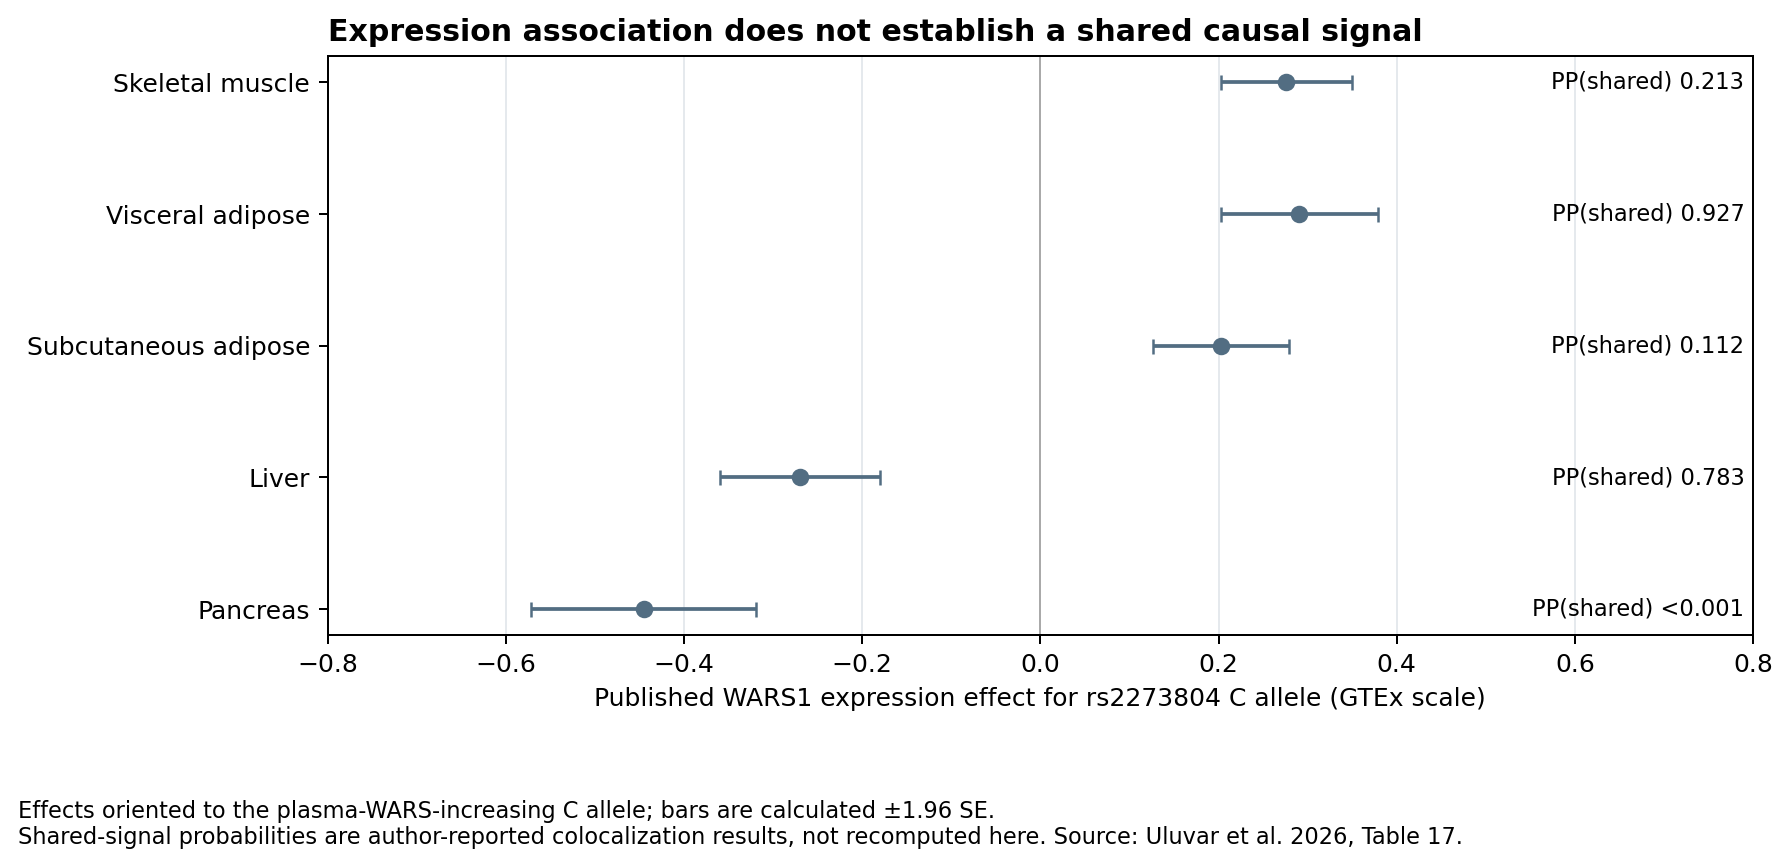

In [6]:
fig,ax=plt.subplots(figsize=(10,4.8))
pretty={'Muscle_Skeletal':'Skeletal muscle','Adipose_Visceral_Omentum':'Visceral adipose',
        'Adipose_Subcutaneous':'Subcutaneous adipose','Liver':'Liver','Pancreas':'Pancreas'}
y=np.arange(len(eqtl));colors=['#526d82']*len(eqtl)
ax.axvline(0,color='#aaa',lw=.8)
for i,row in eqtl.iterrows():
    ax.errorbar(row.eqtl_beta_C,i,xerr=1.96*row.slope_se,fmt='o',color=colors[i],capsize=3)
ax.set_yticks(y,[pretty[t] for t in eqtl.tissue]);ax.invert_yaxis()
ax.set_xlim(-.8,.8);ax.grid(axis='x',color='#e5e9ed');ax.set_axisbelow(True)
ax.set_xlabel('Published WARS1 expression effect for rs2273804 C allele (GTEx scale)')
ax.set_title('Expression association does not establish a shared causal signal',loc='left',fontweight='bold',fontsize=12)
for i,row in eqtl.iterrows():
    probability=row['PP.H4.abf']
    label=f'{probability:.3f}' if probability>=.001 else '<0.001'
    ax.text(.79,i,'PP(shared) '+label,ha='right',va='center',fontsize=9)
fig.text(.01,.01,'Effects oriented to the plasma-WARS-increasing C allele; bars are calculated ±1.96 SE.\nShared-signal probabilities are author-reported colocalization results, not recomputed here. Source: Uluvar et al. 2026, Table 17.',fontsize=9)
fig.tight_layout(rect=(0,.13,1,1));save_figure(fig,'wars1_published_tissue_genetics')

## Available metabolite context: can excess tryptophan explain the exercise signal?

We examined only the literature-motivated metabolites **tryptophan and kynurenine** in the existing human tables. At the WARS1 plasma peak (RE, post 10 min), circulating tryptophan has effect −0.035 and source q = 0.360; muscle tryptophan has no source-q < 0.05 response. The sampled data therefore do not demonstrate excess tryptophan alongside that peak. They also cannot measure local substrate concentrations or exclude an unsampled change.

**Correction limitation:** The original metabolite adjusted values could not be reproduced using either assay/contrast or platform/contrast families from the available tables. We preserve the source values, save both diagnostics, and make no claim of independent BH verification for these metabolites. This does not show that the source correction is wrong; its exact original correction universe/grouping remains unresolved here. Metabolite results are exploratory context and do not affect the WARS1 nomination.

We do not infer a kynurenine/tryptophan ratio, flux, or within-person correlation from separate model summaries.

In [7]:
met=res['metabolites']
display(met[met.contrast_type.eq('exercise_with_controls') & met.tissue.isin(['blood','muscle'])][
    ['tissue','platform','feature_id','contrast_category','sample_time','logFC','p_value','adj_p_value']])
display(pd.read_csv(OUT/'metabolite_BH_reproduction_limits.csv'))

,tissue,platform,feature_id,contrast_category,sample_time,logFC,p_value,adj_p_value
0,blood,metab-u-hilicpos,Tryptophan,EE-CON,During 20 min,0.025354,3.972330e-01,0.576894
1,blood,metab-u-rppos,Kynurenine,EE-CON,During 20 min,0.117186,2.407085e-02,0.137131
2,blood,metab-u-hilicpos,Tryptophan,EE-CON,During 40 min,-0.004544,8.801816e-01,0.924420
3,blood,metab-u-rppos,Kynurenine,EE-CON,During 40 min,-0.015882,7.601706e-01,0.887653
4,blood,metab-u-hilicpos,Tryptophan,EE-CON,Post 10 min,-0.153470,4.734411e-07,0.000006
5,blood,metab-u-rppos,Kynurenine,EE-CON,Post 10 min,-0.146418,5.408816e-03,0.029053
6,blood,metab-u-hilicpos,Tryptophan,EE-CON,Post 30 min,0.047071,1.133079e-01,0.309042
7,blood,metab-u-rppos,Kynurenine,EE-CON,Post 30 min,-0.065795,2.013117e-01,0.573267
8,blood,metab-u-hilicpos,Tryptophan,EE-CON,Post 3.5 h,-0.015774,6.894618e-01,0.972068
9,blood,metab-u-rppos,Kynurenine,EE-CON,Post 3.5 h,0.068171,3.181020e-01,0.843983


,source_object,attempted_family,max_difference,interpretation
0,BLOOD_METAB_DA,tissue;assay;platform;contrast,0.439330,Source q retained; this grouping is not an independent reproduction of source correction
1,BLOOD_METAB_DA,tissue;assay;contrast,0.577447,Source q retained; this grouping is not an independent reproduction of source correction
2,MUSCLE_METAB_DA,tissue;assay;platform;contrast,0.424085,Source q retained; this grouping is not an independent reproduction of source correction
3,MUSCLE_METAB_DA,tissue;assay;contrast,0.711565,Source q retained; this grouping is not an independent reproduction of source correction
4,ADIPOSE_METAB_DA,tissue;assay;platform;contrast,0.481043,Source q retained; this grouping is not an independent reproduction of source correction
5,ADIPOSE_METAB_DA,tissue;assay;contrast,0.832398,Source q retained; this grouping is not an independent reproduction of source correction


## Testable hypotheses and what is still missing

| Hypothesis | Current supporting observation | Discriminating test |
|---|---|---|
| RE produces an active extracellular WARS1 signal | Early Olink increase, with independent literature demonstrating secretion | Verify the signal using orthogonal protein detection; distinguish soluble and vesicular fractions, fragments and full-length protein, and monitor cell-injury/plasma-volume explanations |
| A particular WARS1 form alters vascular or immune function | Known mini-WARS/T2-WARS and immune mechanisms outside exercise | Compare pre/post-exercise plasma with WARS1 depletion and form-specific add-back in endothelial-barrier and innate-immune readouts; include specificity and endotoxin controls |
| Muscle transcription replenishes a released pool | Later muscle RNA induction | Establish source using cell-resolved expression and direct tissue release measurements; temporal overlap alone is insufficient |
| Metabolic context separates an acute pulse from a disease-associated WARS1 state | Experimental insulin mechanism and published genetic associations | Separately perturb intracellular WARS under normal/elevated tryptophan and quantify IR K1209 modification, insulin-stimulated signaling and glucose uptake; do not substitute extracellular-protein addition for this intracellular experiment |

The existing summary data can establish differential responses, audit comparisons, and integrate published disease associations. They cannot determine secretory origin, active isoform, receptor engagement, insulin sensitivity, or participant-level coupling. Raw RNA junction/isoform data and form-resolving protein measurements would be needed to distinguish splice/cleavage mechanisms.

WARS1 was absent from the checked MoTrPAC Table S8 under WARS1/WARS, but a 2015 pilot report already discussed tryptophanyl-tRNA-synthetase transcription in athletes and overtraining. That is prior exercise-related literature, not evidence for plasma secretion or confirmation of our acute result. We do not claim first discovery. [Journal issue containing the report](https://genescells.ru/2313-1829/issue/view/6122).

All source contrasts, the assay-coverage table, BH audit, published disease/tissue-QTL extracts, figures, and checksummed provenance are saved in `results/wars1/`. The earlier notebooks remain unchanged.